<a href="https://colab.research.google.com/github/HinaH1/dental-caries-segmentation/blob/main/notebooks/Dental_caries_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dental Caries Segmentation in Periapical Radiographs Using YOLOv8**

---

## **Project Overview**
This notebook documents the development, training, and evaluation of a YOLOv8 segmentation model for detecting dental caries in periapical radiographs.

---

## **Project Information**
- **Author:** Hina Habib  
- **Degree:** BSc Computer Science  
- **Project Type:** Final Year Dissertation  
- **Model Architecture:** Ultralytics YOLOv8 (Segmentation)  
- **Dataset:** Periapical Radiographs (Caries Only)  
- **Last Updated:** 2 March 2026  

---

## 1. **Dataset Acquisition**

The dataset was downloaded from Roboflow in YOLOv8 segmentation format.  
This ensures compatibility with the Ultralytics YOLOv8 training pipeline.

The dataset contains periapical radiographs annotated for dental caries using polygon segmentation masks.

The version downloaded reflects the cleaned dataset where:
- Only the **caries** class is retained
- The **restoration** class has been removed

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gKXgpQfXZcLo2AjGBatg")
project = rf.workspace("hinas-workspace").project("tumverilerdeneme-ap2eh")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to tümverilerdeneme-2 in yolov8:: 100%|██████████| 1904/1904 [00:00<00:00, 8056.87it/s]


## 2. **Dataset Structure Verification**

After downloading the dataset, the directory structure was inspected to ensure correct YOLOv8 formatting.

Expected YOLOv8 structure:

```bash
dataset/
├── train/
│   ├── images/
│   ├── labels/
├── valid/
│   ├── images/
│   ├── labels/
├── test/
│   ├── images/
│   ├── labels/
└── data.yaml
```

This structure is required for successful training using Ultralytics YOLOv8.

In [2]:
!ls

sample_data  tümverilerdeneme-2


In [3]:
!ls tümverilerdeneme-2

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [5]:
!ls tümverilerdeneme-2/train

images	labels


# **Annotation Sanity Check (Image–Label Alignment)**

Before training the model, a validation step was performed to ensure that segmentation annotations correctly align with their corresponding radiographs.

This process:
- Selects a random image containing caries (non-empty label file)
- Loads the associated YOLOv8 segmentation label
- Converts normalised polygon coordinates to pixel coordinates
- Overlays the segmentation mask on the original image

This verification step helps prevent training errors caused by incorrectly formatted or misaligned annotations.

Selected image: 207_jpg.rf.7eff17c77734eccdd2fd5d5330004a80.jpg
Number of segmentation instances: 1


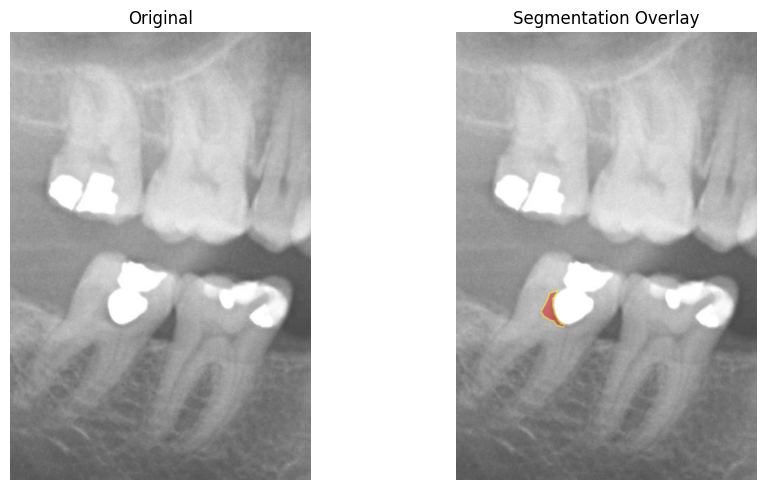

In [25]:
import cv2
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt

# Paths
base_path = Path("tümverilerdeneme-2/train")
img_dir = base_path / "images"
label_dir = base_path / "labels"

# Select only images with non-empty labels (contain caries)
valid_images = []

for label_file in label_dir.glob("*.txt"):
    if label_file.stat().st_size > 0:
        image_file = img_dir / (label_file.stem + ".jpg")
        if image_file.exists():
            valid_images.append(image_file)

# Randomly choose one valid image
img_path = random.choice(valid_images)
label_path = label_dir / (img_path.stem + ".txt")

print("Selected image:", img_path.name)

# Load image
original = cv2.imread(str(img_path))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
overlay = original.copy()

h, w = original.shape[:2]

# Draw segmentation polygons
with open(label_path, "r") as f:
    lines = f.readlines()

print("Number of segmentation instances:", len(lines))

for line in lines:
    parts = line.strip().split()
    coords = list(map(float, parts[1:]))

    points = []
    for i in range(0, len(coords), 2):
        x = int(coords[i] * w)
        y = int(coords[i+1] * h)
        points.append((x, y))

    points = np.array(points, np.int32)

    cv2.fillPoly(overlay, [points], color=(255, 0, 0))
    cv2.polylines(overlay, [points], True, (255, 255, 0), 2)

# Blend overlay
alpha = 0.4
output = cv2.addWeighted(overlay, alpha, original, 1 - alpha, 0)

# Plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Segmentation Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

### Verification Result

The overlayed segmentation regions align correctly with the visible carious lesions in the radiograph.

This confirms that:
- The YOLOv8 label format has been parsed correctly.
- Polygon coordinates are correctly scaled from normalised values to pixel space.
- Image–label correspondence is valid.

The dataset is therefore correctly formatted and ready for model training.

## 3. Label Distribution Analysis

To understand dataset composition, label files were analysed to determine:

- Total number of label files
- Number of non-empty label files (images containing caries)
- Number of empty label files (images without caries)

This helps assess class distribution and potential imbalance in the dataset.

In [22]:
from pathlib import Path

label_dir = Path("tümverilerdeneme-2/train/labels")

total_labels = list(label_dir.glob("*.txt"))

non_empty = [f for f in total_labels if f.stat().st_size > 0]

print("Total label files:", len(total_labels))
print("Images with caries:", len(non_empty))

Total label files: 757
Images with caries: 434


### Dataset Statistics

- Total label files: 757  
- Images containing caries (non-empty labels): 343  
- Images without caries: 414  

This indicates that approximately 45% of the dataset contains caries annotations, while 55% contain no caries.

This imbalance is important to consider during training, as the model may otherwise bias toward predicting the absence of caries.